# Face expressio detection with HOG and SVM classifiers

Imports

In [2]:
import time
from pathlib import Path
import cv2
import joblib
import numpy as np
from skimage.feature import hog
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.multiclass import (
    OneVsRestClassifier,
)  # In case we use it instead of manually training one binary SVM per emotion
import matplotlib.pyplot as plt

Dataset management utilities

In [4]:
# Explicit mapping from folder names to integer labels [0..6]
FOLDER_TO_LABEL = {
    "angry": 0,
    "disgust": 1,
    "fear": 2,
    "happy": 3,
    "sad": 4,
    "surprise": 5,
    "neutral": 6,
}

# FER-2013 standard label mapping
EMOTIONS = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral",
}


# Dataset loading utilities


def load_fer2013_split(split_dir: Path) -> tuple[np.ndarray, np.ndarray]:
    """
    Loads all 48x48 grayscale images and labels from the given split directory (train or test).
    """
    images = []
    labels = []

    if not split_dir.exists():
        raise FileNotFoundError(f"Directory not found: {split_dir.resolve()}")

    for emotion_name, label_idx in FOLDER_TO_LABEL.items():
        emotion_dir = split_dir / emotion_name
        if not emotion_dir.is_dir():
            print(f"[Warning] Missing folder: {emotion_dir}")
            continue

        # Grab all common image extensions (.jpg, .png, .jpeg)
        image_files = (
            list(emotion_dir.glob("*.jpg"))
            + list(emotion_dir.glob("*.png"))
            + list(emotion_dir.glob("*.jpeg"))
        )

        for img_path in image_files:
            # Load directly as single-channel grayscale (uint8)
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            # Safeguard in case an image isn't strictly 48x48
            if img.shape != (48, 48):
                print(
                    f"[Warning] Resizing image {img_path} from {img.shape} to (48, 48). THIS SHOULD NOT HAPPEN"
                )
                img = cv2.resize(img, (48, 48), interpolation=cv2.INTER_AREA)

            images.append(img)
            labels.append(label_idx)

    X = np.array(images, dtype=np.uint8)
    y = np.array(labels, dtype=np.int64)

    # Shuffle the split so classes aren't grouped in contiguous blocks
    rng = np.random.default_rng(42)
    indices = rng.permutation(len(X))

    return X[indices], y[indices]


def load_fer2013_dataset(archive_path: str = "archive"):
    """
    Loads both 'train' and 'test' splits from the archive folder.
    Returns: X_train, y_train, X_test, y_test
    """
    base_dir = Path(archive_path)

    print(f"Loading training set from {base_dir / 'train'}...")
    X_train, y_train = load_fer2013_split(base_dir / "train")
    print(f" -> Loaded {X_train.shape[0]} train images of shape {X_train.shape[1:]}")

    print(f"Loading test set from {base_dir / 'test'}...")
    X_test, y_test = load_fer2013_split(base_dir / "test")
    print(f" -> Loaded {X_test.shape[0]} test images of shape {X_test.shape[1:]}")

    return X_train, y_train, X_test, y_test

HOG features extraction utilities

In [5]:
def extract_hog_single(image_48x48: np.ndarray) -> np.ndarray:
    """
    Computes the HOG descriptor for a single 48x48 grayscale image.

    Dimension math for 48x48 input:
    - pixels_per_cell = (8, 8) -> 6x6 cells
    - cells_per_block = (2, 2) with 1-cell stride -> 5x5 = 25 blocks
    - orientations = 9 bins -> 25 blocks * (2*2 cells) * 9 bins = 900 features
    """
    features = hog(
        image_48x48,
        orientations=9,
        pixels_per_cell=(8, 8),  # Size of one cell in pixels
        cells_per_block=(2, 2),  # Group 2x2 neighboring cells into a block
        block_norm="L2",  # L2 normalization (with clipping) for illumination invariance # TODO: put back L2-hys ?
        transform_sqrt=True,  # Gamma/power law compression before gradients (helps with shadows) # TODO disablig it did not give better results
        feature_vector=True,  # Concatenates all normalized block histograms into a 1D vector
    )
    return features


def extract_hog_batch(images: np.ndarray) -> np.ndarray:
    """
    Extracts HOG features for an array of images of shape (N, 48, 48).
    Returns array of shape (N, 900).
    """
    return np.array([extract_hog_single(img) for img in images], dtype=np.float32)

SVM classifiers training

For now, we use a linear SVM, mostly because it is faster to train than a RBF SVM.

In [25]:
def train_pipeline(
    X_train_imgs: np.ndarray,
    y_train: np.ndarray,
    X_val_imgs: np.ndarray,
    y_val: np.ndarray,
    checkpoint_dir: str = "checkpoints",
):
    """
    Extracts HOG descriptors, scales features, and trains 7 independent binary SVMs
    one after the other in the 'emotion vs rest' pattern.
    """
    ckpt_path = Path(checkpoint_dir)
    ckpt_path.mkdir(parents=True, exist_ok=True)

    print("\n[1/3] Extracting HOG descriptors...")
    X_train_hog = extract_hog_batch(X_train_imgs)
    X_val_hog = extract_hog_batch(X_val_imgs)
    print(f"      Descriptor shape per image: {X_train_hog.shape[1]} features")

    # Standardize features across the dataset (zero mean, unit variance) before SVM
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_hog)
    X_val_scaled = scaler.transform(X_val_hog)

    # Save the scaler immediately so checkpoints can be used standalone
    joblib.dump(scaler, ckpt_path / "hog_scaler.pkl")

    print("\n[2/3] Training 7 individual SVMs sequentially (Emotion vs Rest)...")
    classifiers = {}
    val_scores_matrix = np.zeros((len(X_val_scaled), len(EMOTIONS)), dtype=np.float64)

    for emotion_idx, emotion_name in EMOTIONS.items():
        t0 = time.time()

        # Binary target: +1 for the current emotion, -1 for the other 6 emotions ("rest")
        y_train_binary = np.where(y_train == emotion_idx, 1, -1)
        y_val_binary = np.where(y_val == emotion_idx, 1, -1)

        n_pos = int(np.sum(y_train_binary == 1))
        n_neg = int(np.sum(y_train_binary == -1))
        print(
            f"  -> [{emotion_idx + 1}/7] Training '{emotion_name} vs Rest' "
            f"(+1: {n_pos} imgs | -1: {n_neg} imgs)..."
        )

        # Single binary SVM for this emotion
        # clf = SVC(
        #     kernel="rbf",
        #     C=1.0,
        #     gamma="scale",
        #     class_weight="balanced",
        #     cache_size=1000,
        #     # 1 GB kernel cache for faster SMO convergence
        # )

        clf = LinearSVC(
            C=0.1,
            loss="squared_hinge",
            dual=False,  # Primal formulation : BEAUCOUP plus rapide quand N_échantillons >> N_features
            class_weight="balanced",  # Indispensable en One-vs-Rest
            max_iter=2000,  # Lowering the value to 1000 did not change anything
            random_state=42,
        )
        clf.fit(X_train_scaled, y_train_binary)
        elapsed = time.time() - t0

        # Evaluate this binary classifier on the validation set
        scores = clf.decision_function(X_val_scaled)
        val_scores_matrix[:, emotion_idx] = scores
        auc = roc_auc_score(y_val_binary, scores)
        print(f"     Done in {elapsed:.1f}s | Binary ROC-AUC: {auc:.3f}")

        # Save individual SVM checkpoint immediately
        model_file = ckpt_path / f"svm_ovr_{emotion_idx}_{emotion_name.lower()}.pkl"
        joblib.dump(clf, model_file)
        classifiers[emotion_idx] = clf

    print("\n[3/3] Evaluating combined 7-SVM One-vs-Rest model on validation set...")
    # Multi-class prediction: pick the classifier with the highest signed hyperplane distance
    y_pred = np.argmax(val_scores_matrix, axis=1)
    acc = accuracy_score(y_val, y_pred)
    print(f"Validation Accuracy: {acc * 100:.2f}%\n")
    print(classification_report(y_val, y_pred, target_names=list(EMOTIONS.values())))

    return classifiers, scaler

Train pipeline for RBF onevsrest classifiers

In [5]:
def train_pipeline_rbf(
    X_train_imgs: np.ndarray,
    y_train: np.ndarray,
    X_val_imgs: np.ndarray,
    y_val: np.ndarray,
):
    """
    Extracts HOG descriptors, scales features, and trains 7 SVMs in an
    'emotion vs rest' (One-vs-Rest) pattern.
    """
    print("[1/3] Extracting HOG descriptors...")
    X_train_hog = extract_hog_batch(X_train_imgs)
    X_val_hog = extract_hog_batch(X_val_imgs)
    print(f"      Descriptor shape per image: {X_train_hog.shape[1]} features")

    # Standardize features across the dataset (zero mean, unit variance) before SVM
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_hog)
    X_val_scaled = scaler.transform(X_val_hog)

    print("[2/3] Training 7 SVMs (One-vs-Rest)...")
    # Base binary classifier: RBF kernel works significantly better than linear on FER-2013
    # class_weight='balanced' helps counter the heavy imbalance in FER-2013 (e.g., Disgust has very few samples)
    base_svm = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=False,  # Decision function is faster and sufficient for OvR argmax
        cache_size=1000,
    )

    # OneVsRestClassifier explicitly fits 1 binary classifier per emotion (7 total)
    # n_jobs=-1 parallelizes training of the 7 classifiers across all CPU cores
    ovr_svm = OneVsRestClassifier(base_svm, n_jobs=-1)
    ovr_svm.fit(X_train_scaled, y_train)

    print("[3/3] Evaluating on validation set...")
    y_pred = ovr_svm.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_pred)
    print(f"Validation Accuracy: {acc * 100:.2f}%\n")
    print(classification_report(y_val, y_pred, target_names=list(EMOTIONS.values())))

    return ovr_svm, scaler

Launch the training of the SVM classifiers

In [6]:
# Import the FER2013 dataset that is in the archive folder
X_train, y_train, X_test, y_test = load_fer2013_dataset("archive")

Loading training set from archive/train...
 -> Loaded 28709 train images of shape (48, 48)
Loading test set from archive/test...
 -> Loaded 7178 test images of shape (48, 48)


In [26]:
# 1. Train the 7 individual SVMs one after the other
trained_classifiers, fitted_scaler = train_pipeline(X_train, y_train, X_test, y_test)

# Save complete bundle (dict of 7 SVMs + scaler) for easy loading later
joblib.dump(
    {"classifiers": trained_classifiers, "scaler": fitted_scaler},
    "hog_svm_fer2013.pkl",
)


[1/3] Extracting HOG descriptors...
      Descriptor shape per image: 900 features

[2/3] Training 7 individual SVMs sequentially (Emotion vs Rest)...
  -> [1/7] Training 'Angry vs Rest' (+1: 3995 imgs | -1: 24714 imgs)...
     Done in 31.2s | Binary ROC-AUC: 0.708
  -> [2/7] Training 'Disgust vs Rest' (+1: 436 imgs | -1: 28273 imgs)...
     Done in 26.0s | Binary ROC-AUC: 0.858
  -> [3/7] Training 'Fear vs Rest' (+1: 4097 imgs | -1: 24612 imgs)...
     Done in 33.0s | Binary ROC-AUC: 0.668
  -> [4/7] Training 'Happy vs Rest' (+1: 7215 imgs | -1: 21494 imgs)...
     Done in 26.2s | Binary ROC-AUC: 0.847
  -> [5/7] Training 'Sad vs Rest' (+1: 4830 imgs | -1: 23879 imgs)...
     Done in 33.2s | Binary ROC-AUC: 0.704
  -> [6/7] Training 'Surprise vs Rest' (+1: 3171 imgs | -1: 25538 imgs)...
     Done in 27.3s | Binary ROC-AUC: 0.881
  -> [7/7] Training 'Neutral vs Rest' (+1: 4965 imgs | -1: 23744 imgs)...
     Done in 28.7s | Binary ROC-AUC: 0.738

[3/3] Evaluating combined 7-SVM One-vs-

['hog_svm_fer2013.pkl']

In [7]:
# For RBF One-vs-Rest
trained_ovr_svm, fitted_scaler = train_pipeline_rbf(X_train, y_train, X_test, y_test)

# Optional: Save model & scaler for later use
joblib.dump({"model": trained_ovr_svm, "scaler": fitted_scaler}, "hog_svm_fer2013.pkl")

[1/3] Extracting HOG descriptors...
      Descriptor shape per image: 900 features
[2/3] Training 7 SVMs (One-vs-Rest)...


/home/pierre/Documents/ENSTA/3A/RO11_apprentissage_robotique/KNN_facial_expression/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pierre/Documents/ENSTA/3A/RO11_apprentissage_robotique/KNN_facial_expression/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pierre/Documents/ENSTA/3A/RO11_apprentissage_robotique/KNN_facial_expression/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` in

[3/3] Evaluating on validation set...
Validation Accuracy: 57.93%

              precision    recall  f1-score   support

       Angry       0.47      0.43      0.44       958
     Disgust       0.95      0.51      0.67       111
        Fear       0.52      0.39      0.45      1024
       Happy       0.70      0.79      0.74      1774
         Sad       0.45      0.48      0.47      1247
    Surprise       0.76      0.71      0.74       831
     Neutral       0.51      0.57      0.54      1233

    accuracy                           0.58      7178
   macro avg       0.62      0.55      0.58      7178
weighted avg       0.58      0.58      0.58      7178



['hog_svm_fer2013.pkl']

Results with firts version of the training pipeline
```
[2/3] Training 7 individual SVMs sequentially (Emotion vs Rest)...
  -> [1/7] Training 'Angry vs Rest' (+1: 3995 imgs | -1: 24714 imgs)...
     Done in 30.2s | Binary ROC-AUC: 0.706
  -> [2/7] Training 'Disgust vs Rest' (+1: 436 imgs | -1: 28273 imgs)...
     Done in 24.6s | Binary ROC-AUC: 0.863
  -> [3/7] Training 'Fear vs Rest' (+1: 4097 imgs | -1: 24612 imgs)...
     Done in 32.7s | Binary ROC-AUC: 0.657
  -> [4/7] Training 'Happy vs Rest' (+1: 7215 imgs | -1: 21494 imgs)...
     Done in 21.6s | Binary ROC-AUC: 0.852
  -> [5/7] Training 'Sad vs Rest' (+1: 4830 imgs | -1: 23879 imgs)...
     Done in 30.5s | Binary ROC-AUC: 0.694
  -> [6/7] Training 'Surprise vs Rest' (+1: 3171 imgs | -1: 25538 imgs)...
     Done in 26.1s | Binary ROC-AUC: 0.866
  -> [7/7] Training 'Neutral vs Rest' (+1: 4965 imgs | -1: 23744 imgs)...
     Done in 28.8s | Binary ROC-AUC: 0.729

[3/3] Evaluating combined 7-SVM One-vs-Rest model on validation set...
Validation Accuracy: 41.38%

              precision    recall  f1-score   support

       Angry       0.29      0.30      0.29       958
     Disgust       0.13      0.50      0.21       111
        Fear       0.28      0.22      0.25      1024
       Happy       0.63      0.63      0.63      1774
         Sad       0.32      0.26      0.28      1247
    Surprise       0.48      0.56      0.51       831
     Neutral       0.41      0.41      0.41      1233

    accuracy                           0.41      7178
   macro avg       0.36      0.41      0.37      7178
weighted avg       0.42      0.41      0.41      7178
```

Results with L2 instead of L2-HYS - It does perform better !
```
[2/3] Training 7 individual SVMs sequentially (Emotion vs Rest)...
  -> [1/7] Training 'Angry vs Rest' (+1: 3995 imgs | -1: 24714 imgs)...
     Done in 33.0s | Binary ROC-AUC: 0.708
  -> [2/7] Training 'Disgust vs Rest' (+1: 436 imgs | -1: 28273 imgs)...
     Done in 24.0s | Binary ROC-AUC: 0.858
  -> [3/7] Training 'Fear vs Rest' (+1: 4097 imgs | -1: 24612 imgs)...
     Done in 31.4s | Binary ROC-AUC: 0.668
  -> [4/7] Training 'Happy vs Rest' (+1: 7215 imgs | -1: 21494 imgs)...
     Done in 23.7s | Binary ROC-AUC: 0.847
  -> [5/7] Training 'Sad vs Rest' (+1: 4830 imgs | -1: 23879 imgs)...
     Done in 29.4s | Binary ROC-AUC: 0.704
  -> [6/7] Training 'Surprise vs Rest' (+1: 3171 imgs | -1: 25538 imgs)...
     Done in 28.6s | Binary ROC-AUC: 0.881
  -> [7/7] Training 'Neutral vs Rest' (+1: 4965 imgs | -1: 23744 imgs)...
     Done in 29.4s | Binary ROC-AUC: 0.738

[3/3] Evaluating combined 7-SVM One-vs-Rest model on validation set...
Validation Accuracy: 43.47%

              precision    recall  f1-score   support

       Angry       0.32      0.32      0.32       958
     Disgust       0.14      0.57      0.23       111
        Fear       0.32      0.26      0.29      1024
       Happy       0.65      0.63      0.64      1774
         Sad       0.34      0.28      0.31      1247
    Surprise       0.51      0.60      0.55       831
     Neutral       0.42      0.41      0.41      1233

    accuracy                           0.43      7178
   macro avg       0.39      0.44      0.39      7178
weighted avg       0.44      0.43      0.43      7178
```

Résultats avec L2 et transform_sqrt=False - pas mieux
```
[2/3] Training 7 individual SVMs sequentially (Emotion vs Rest)...
  -> [1/7] Training 'Angry vs Rest' (+1: 3995 imgs | -1: 24714 imgs)...
     Done in 36.8s | Binary ROC-AUC: 0.708
  -> [2/7] Training 'Disgust vs Rest' (+1: 436 imgs | -1: 28273 imgs)...
     Done in 29.1s | Binary ROC-AUC: 0.867
  -> [3/7] Training 'Fear vs Rest' (+1: 4097 imgs | -1: 24612 imgs)...
     Done in 36.3s | Binary ROC-AUC: 0.672
  -> [4/7] Training 'Happy vs Rest' (+1: 7215 imgs | -1: 21494 imgs)...
     Done in 31.3s | Binary ROC-AUC: 0.848
  -> [5/7] Training 'Sad vs Rest' (+1: 4830 imgs | -1: 23879 imgs)...
     Done in 31.0s | Binary ROC-AUC: 0.702
  -> [6/7] Training 'Surprise vs Rest' (+1: 3171 imgs | -1: 25538 imgs)...
     Done in 32.2s | Binary ROC-AUC: 0.869
  -> [7/7] Training 'Neutral vs Rest' (+1: 4965 imgs | -1: 23744 imgs)...
     Done in 36.9s | Binary ROC-AUC: 0.732

[3/3] Evaluating combined 7-SVM One-vs-Rest model on validation set...
Validation Accuracy: 43.03%

              precision    recall  f1-score   support

       Angry       0.31      0.31      0.31       958
     Disgust       0.13      0.55      0.22       111
        Fear       0.32      0.26      0.28      1024
       Happy       0.64      0.64      0.64      1774
         Sad       0.35      0.28      0.31      1247
    Surprise       0.49      0.57      0.53       831
     Neutral       0.43      0.42      0.42      1233

    accuracy                           0.43      7178
   macro avg       0.38      0.43      0.39      7178
weighted avg       0.44      0.43      0.43      7178
```

Finally, with a RBF kernel, we obtain a better accuracy, but the training time is much longer (it took me about 35 minutes + 10 minutes of evaluation on the validation set. Plus, the model is huge ! 800MB !

```
Validation Accuracy: 57.93%

              precision    recall  f1-score   support

       Angry       0.47      0.43      0.44       958
     Disgust       0.95      0.51      0.67       111
        Fear       0.52      0.39      0.45      1024
       Happy       0.70      0.79      0.74      1774
         Sad       0.45      0.48      0.47      1247
    Surprise       0.76      0.71      0.74       831
     Neutral       0.51      0.57      0.54      1233

    accuracy                           0.58      7178
   macro avg       0.62      0.55      0.58      7178
weighted avg       0.58      0.58      0.58      7178
```

# Inference

In [13]:
def predict_single_image(
    image_path: str,
    classifiers: dict[int, SVC],
    scaler: StandardScaler,
):
    """
    Loads an external image, converts/resizes to 48x48 grayscale,
    computes its HOG descriptor, and queries each of the 7 binary SVMs.
    """
    # Load image in grayscale
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not load image at: {image_path}")
    img = cv2.cvtColor(
        img, cv2.COLOR_BGR2GRAY
    )  # TODO utiliser seulement imread avec cv2.IMREAD_GRAYSCALE

    haar_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    if haar_cascade.empty():
        raise RuntimeError("Failed to load Haar cascade classifier for face detection.")

    faces = haar_cascade.detectMultiScale(img, scaleFactor=1.1, minNeighbors=5)

    face = faces[0] if len(faces) > 0 else None

    if faces is None:
        print("No face detected in the image.")
        return None, None

    faces_results = []
    for face in faces:
        x, y, w, h = face
        # Crop the detected face region
        img_face = img[y : y + h, x : x + w].copy()

        # Ensure 48x48 dimensions
        if img_face.shape != (48, 48):
            img_face = cv2.resize(img_face, (48, 48), interpolation=cv2.INTER_AREA)

        # Show the preprocessed face image for debugging with plt
        plt.imshow(img_face, cmap="gray")
        plt.show()

        # 1. Compute 1D HOG vector (shape: (900,)) and reshape to (1, 900)
        hog_vec = extract_hog_single(img_face).reshape(1, -1)

        # 2. Scale using the training scaler
        hog_scaled = scaler.transform(hog_vec)

        # 3. Query each of the 7 binary SVMs for its signed hyperplane distance
        decision_scores = np.zeros(len(EMOTIONS), dtype=np.float64)
        for emotion_idx, clf in classifiers.items():
            decision_scores[emotion_idx] = float(clf.decision_function(hog_scaled)[0])

        # 4. Pick the classifier with the highest score
        predicted_class_idx = int(np.argmax(decision_scores))
        predicted_emotion = EMOTIONS[predicted_class_idx]
        # Print the predicted emotion and the decision scores
        print(f"Predicted emotion: {predicted_emotion}")
        print("Decision scores per emotion:")
        for idx, score in enumerate(decision_scores):
            print(f"  {EMOTIONS[idx]}: {score:.4f}")

        faces_results.append((face, predicted_emotion, decision_scores))
    return faces_results

In [8]:
# Load the trained SVMs and scaler from the saved bundle
bundle_linear = joblib.load("hog_svm_fer2013_linear.pkl")
trained_classifiers_linear_inference = bundle_linear["classifiers"]
fitted_scaler_linear_inference = bundle_linear["scaler"]

# load the RBF SVM and scaler from the saved bundle
bundle_rbf = joblib.load("hog_svm_fer2013_rbf.pkl")
model_rbf_inference = bundle_rbf["model"]
fitted_scaler_rbf_inference = bundle_rbf["scaler"]


Processing image: happy.jpg


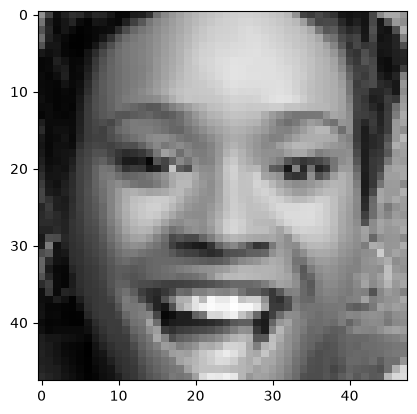

Predicted emotion: Happy
Decision scores per emotion:
  Angry: -0.0540
  Disgust: -2.0268
  Fear: -0.5178
  Happy: 0.2675
  Sad: -0.7196
  Surprise: -0.4388
  Neutral: -0.6082


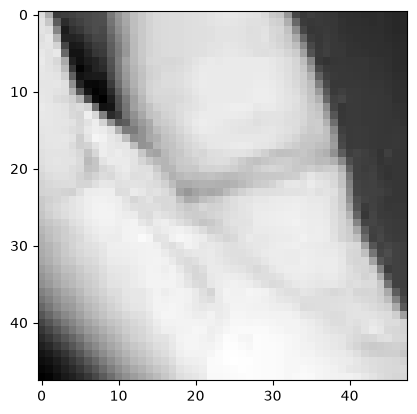

Predicted emotion: Angry
Decision scores per emotion:
  Angry: 0.7313
  Disgust: -3.9067
  Fear: 0.2231
  Happy: -1.1233
  Sad: -0.0565
  Surprise: -0.9739
  Neutral: -0.0113

Processing image: sad.avif


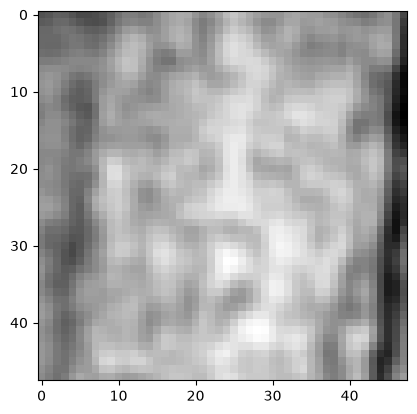

Predicted emotion: Sad
Decision scores per emotion:
  Angry: -0.0844
  Disgust: -3.3010
  Fear: -0.6565
  Happy: -0.0245
  Sad: 0.1888
  Surprise: -0.2829
  Neutral: -0.0878


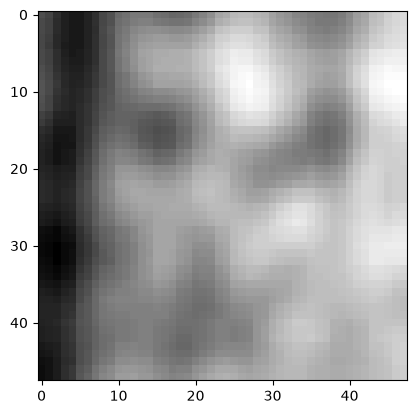

Predicted emotion: Neutral
Decision scores per emotion:
  Angry: -0.3080
  Disgust: -0.9050
  Fear: 0.4032
  Happy: -1.0328
  Sad: 0.5228
  Surprise: -0.8286
  Neutral: 0.5918


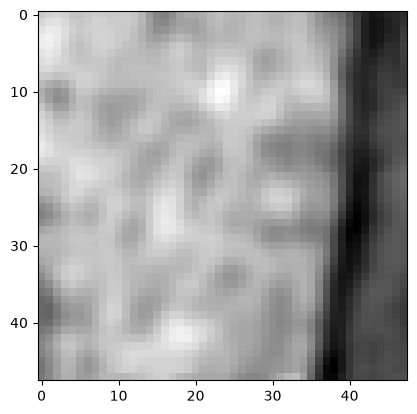

Predicted emotion: Angry
Decision scores per emotion:
  Angry: 0.2285
  Disgust: -0.7797
  Fear: 0.1787
  Happy: -0.4840
  Sad: -0.1096
  Surprise: -0.6160
  Neutral: -0.0873

Processing image: suprised_boy.jpeg


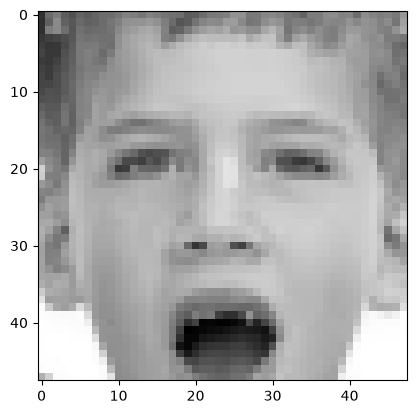

Predicted emotion: Surprise
Decision scores per emotion:
  Angry: -0.4275
  Disgust: -5.9739
  Fear: 0.5921
  Happy: -2.1489
  Sad: -0.1238
  Surprise: 1.0525
  Neutral: -0.0370


In [14]:
for image_path in sorted(Path("test_images").iterdir()):
    if not image_path.is_file():
        continue

    print(f"\nProcessing image: {image_path.name}")
    faces_results = predict_single_image(
        str(image_path),
        trained_classifiers_linear_inference,
        fitted_scaler_linear_inference,
    )

In [18]:
# Live camera detection
camera = cv2.VideoCapture(0)

if not camera.isOpened():
    raise RuntimeError("Could not open the camera.")

haar_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

try:
    while True:
        ret, frame = camera.read()
        if not ret:
            print("Could not read a frame from the camera.")
            break

        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = haar_cascade.detectMultiScale(
            gray_frame,
            scaleFactor=1.1,
            minNeighbors=10,
            minSize=(40, 40),
        )

        for x, y, w, h in faces:
            face = gray_frame[y : y + h, x : x + w]
            face = cv2.resize(face, (48, 48), interpolation=cv2.INTER_AREA)

            hog_vec = extract_hog_single(face).reshape(1, -1)
            hog_scaled = fitted_scaler_linear_inference.transform(hog_vec)

            decision_scores = np.zeros(len(EMOTIONS), dtype=np.float64)
            for emotion_idx, classifier in trained_classifiers_linear_inference.items():
                decision_scores[emotion_idx] = classifier.decision_function(hog_scaled)[
                    0
                ]

            predicted_idx = int(np.argmax(decision_scores))
            predicted_emotion = EMOTIONS[predicted_idx]

            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2,
            )

            cv2.putText(
                frame,
                predicted_emotion,
                (x, max(y - 10, 25)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 0),
                2,
                cv2.LINE_AA,
            )

        cv2.imshow("Live Facial Expression Recognition", frame)

        # Press q to stop
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

finally:
    camera.release()
    cv2.destroyAllWindows()